# STABL baseline binary study-group comparisons

This notebook is the SLURM-cached binary-comparison companion to `scratch/01_stablr_baseline_groups_test.ipynb`. It keeps the same AURORA baseline all-view preprocessing contract, but models three explicit binomial contrasts instead of the original multinomial `EG`/`GA`/`TU` endpoint:

- `EG_vs_GA_TU`: `GA_TU` reference vs `EG` positive.
- `GA_vs_EG`: `EG` reference vs `GA` positive.
- `TU_vs_EG`: `EG` reference vs `TU` positive.

The notebook defaults to consuming caches generated by `scratch/scripts/run_stablr_baseline_comparisons_branch.R` and `scratch/slurm/stablr_baseline_comparisons_*.slurm`. Local refits are disabled by default so opening the notebook does not launch heavy STABL runs.


## Setup And Run Controls

This section defines the contrasts, cache roots, and read-only cache-loading defaults. Set `WRITE_NOTEBOOK_OUTPUTS <- TRUE` only when you want the notebook to rewrite derived summary tables; heavy model fitting should normally be run through SLURM.


In [1]:
# Runtime controls -------------------------------------------------------------
CONTRASTS <- c("EG_vs_GA_TU", "GA_vs_EG", "TU_vs_EG")
ACTIVE_CONTRAST <- Sys.getenv("STABLR_CONTRAST", "EG_vs_GA_TU")
if (!ACTIVE_CONTRAST %in% CONTRASTS) ACTIVE_CONTRAST <- "EG_vs_GA_TU"

LOAD_CACHED_RESULTS <- TRUE
WRITE_NOTEBOOK_OUTPUTS <- FALSE
FORCE_RECOMPUTE <- FALSE

RUN_CYTOF_SANITY_CHECK <- FALSE
RUN_ALL_SINGLE_VIEW_STABL <- FALSE
RUN_ALL_VIEW_EARLY_FUSION <- FALSE
RUN_LATE_FUSION <- FALSE
RUN_COOPERATIVE <- FALSE
RUN_PUBLICATION_NESTED_CV <- FALSE
RUN_CLUSTERING_VISUALIZATIONS <- FALSE

STABLR_SEED <- 20260512L
STABL_FAMILY <- "binomial"
TOP_FEATURES_PER_CONTRAST <- 10L
TOP_HEATMAP_FEATURES <- 50L

CACHE_ROOT <- file.path("scratch", "cache", "stablr_baseline_binary_comparisons")
EXPORT_ROOT <- file.path("scratch", "outputs", "stablr_baseline_binary_comparisons")
HELPER_PATH <- file.path("scratch", "scripts", "stablr_baseline_comparisons_helpers.R")


In [2]:
# Package and helper setup -----------------------------------------------------
find_stablr_repo_root <- function(start = getwd()) {
  path <- normalizePath(start, winslash = "/", mustWork = TRUE)
  repeat {
    if (file.exists(file.path(path, "AGENTS.md")) && dir.exists(file.path(path, "scratch"))) {
      return(path)
    }
    parent <- dirname(path)
    if (identical(parent, path)) break
    path <- parent
  }
  normalizePath(start, winslash = "/", mustWork = TRUE)
}

stablr_repo_root <- find_stablr_repo_root()
resolve_repo_relative_path <- function(path) {
  vapply(path, function(one_path) {
    if (is.na(one_path) || grepl("^(/|[A-Za-z]:[\\/])", one_path)) {
      return(one_path)
    }
    file.path(stablr_repo_root, one_path)
  }, character(1L), USE.NAMES = FALSE)
}

CACHE_ROOT <- resolve_repo_relative_path(CACHE_ROOT)
EXPORT_ROOT <- resolve_repo_relative_path(EXPORT_ROOT)
HELPER_PATH <- resolve_repo_relative_path(HELPER_PATH)
Sys.setenv(STABLR_CACHE_DIR = CACHE_ROOT, STABLR_EXPORT_DIR = EXPORT_ROOT, STABLR_REPO_ROOT = stablr_repo_root)

source(HELPER_PATH)
setup_stablr_for_baseline()

contrast_configs <- purrr::set_names(
  purrr::map(CONTRASTS, baseline_comparisons_config),
  CONTRASTS
)

artifact_path <- function(config, branch, type = c("cache", "table", "figure"), name = NULL, ext = NULL) {
  type <- match.arg(type)
  if (identical(type, "cache")) {
    return(file.path(branch_cache_dir(config, branch), paste0(name, ".rds")))
  }
  if (identical(type, "table")) {
    return(file.path(branch_export_dir(config, branch, "tables"), paste0(name, ".csv")))
  }
  file.path(branch_export_dir(config, branch, "figures"), paste0(name, ".", ext %||% "png"))
}

load_table_if_exists <- function(config, branch, name) {
  path <- artifact_path(config, branch, "table", name)
  if (file.exists(path)) readr::read_csv(path, show_col_types = FALSE) else NULL
}

load_rds_if_exists <- function(config, branch, name) {
  path <- artifact_path(config, branch, "cache", name)
  if (file.exists(path)) readRDS(path) else NULL
}


Warning message:
“package ‘testthat’ was built under R version 4.5.2”
Warning message:
“package ‘dplyr’ was built under R version 4.5.2”
Warning message:
“package ‘tidyr’ was built under R version 4.5.2”
Warning message:
“package ‘ggplot2’ was built under R version 4.5.3”
Warning message:
“package ‘tibble’ was built under R version 4.5.2”
Warning message:
“package ‘readr’ was built under R version 4.5.2”
Warning message:
“package ‘forcats’ was built under R version 4.5.2”


## Contrast Cohort QC

This section loads the contrast-specific preprocessing caches. If a contrast cache is missing, the helper derives it from the original baseline preprocessing cache rather than rerunning imputation and scaling.


In [3]:
contrast_data <- purrr::imap(contrast_configs, function(config, contrast) {
  preprocess_comparison(config, force = isTRUE(FORCE_RECOMPUTE))
})

contrast_counts <- purrr::imap_dfr(contrast_data, function(data, contrast) {
  tibble::tibble(contrast = contrast, outcome = data$y) |>
    dplyr::count(.data$contrast, .data$outcome, name = "n")
})

contrast_study_group_counts <- purrr::imap_dfr(contrast_data, function(data, contrast) {
  data$metadata |>
    tibble::rownames_to_column("sample_id") |>
    dplyr::count(.data$contrast_name, .data$contrast_outcome, .data$study_group, .data$protection, name = "n")
})

contrast_view_qc <- purrr::imap_dfr(contrast_data, function(data, contrast) {
  purrr::imap_dfr(data$x_list, function(x, view) {
    tibble::tibble(
      contrast = contrast,
      view = view,
      n_samples = nrow(x),
      n_features = ncol(x),
      n_missing = sum(is.na(x))
    )
  })
})

contrast_counts
contrast_study_group_counts
contrast_view_qc


contrast,outcome,n
<chr>,<fct>,<int>
EG_vs_GA_TU,GA_TU,28
EG_vs_GA_TU,EG,10
GA_vs_EG,EG,10
GA_vs_EG,GA,16
TU_vs_EG,EG,10
TU_vs_EG,TU,12


contrast_name,contrast_outcome,study_group,protection,n
<chr>,<fct>,<fct>,<fct>,<int>
EG_vs_GA_TU,GA_TU,GA,P,8
EG_vs_GA_TU,GA_TU,GA,NP,8
EG_vs_GA_TU,GA_TU,TU,P,9
EG_vs_GA_TU,GA_TU,TU,NP,3
EG_vs_GA_TU,EG,EG,P,6
EG_vs_GA_TU,EG,EG,NP,4
GA_vs_EG,EG,EG,P,6
GA_vs_EG,EG,EG,NP,4
GA_vs_EG,GA,GA,P,8


contrast,view,n_samples,n_features,n_missing
<chr>,<chr>,<int>,<int>,<int>
EG_vs_GA_TU,cytof_celltype,38,125,0
EG_vs_GA_TU,exvivo_celltype,38,40,0
EG_vs_GA_TU,exvivo_enzyme,38,98,0
EG_vs_GA_TU,6h_cyto_LPS,38,130,0
EG_vs_GA_TU,6h_cyto_ssRNA40,38,130,0
EG_vs_GA_TU,24h_cyto_iRBC,38,157,0
EG_vs_GA_TU,24h_cyto_SEB,38,165,0
EG_vs_GA_TU,24h_enzyme_iRBC,38,94,0
EG_vs_GA_TU,24h_enzyme_SEB,38,99,0


## Cached Branch Status

This table shows whether the expected SLURM-generated cache/table artifacts exist for each contrast. Missing branches should be generated with `scratch/scripts/run_stablr_baseline_comparisons_branch.R` or the paired SLURM scripts.


In [4]:
expected_branch_artifacts <- tibble::tribble(
  ~branch, ~object_type, ~name,
  "preprocess", "cache", "baseline_preprocessed",
  "cytof", "cache", "stabl_fit_bundle",
  "early_fusion", "cache", "stabl_fit_bundle",
  "late_fusion", "cache", "late_fusion_result",
  "cooperative", "cache", "cooperative_fit",
  "nested_cv", "cache", "nested_cv_result",
  "visualize", "cache", "selected_feature_heatmap_matrix"
)

branch_status <- purrr::imap_dfr(contrast_configs, function(config, contrast) {
  expected_branch_artifacts |>
    dplyr::rowwise() |>
    dplyr::mutate(
      contrast = contrast,
      path = artifact_path(config, .data$branch, .data$object_type, .data$name),
      exists = file.exists(.data$path),
      .before = 1L
    ) |>
    dplyr::ungroup()
})

branch_status


contrast,path,exists,branch,object_type,name
<chr>,<chr>,<lgl>,<chr>,<chr>,<chr>
EG_vs_GA_TU,/exports/para-lipg-hpc/mdmanurung/stablr/scratch/cache/stablr_baseline_binary_comparisons/EG_vs_GA_TU/preprocess/baseline_preprocessed.rds,TRUE,preprocess,cache,baseline_preprocessed
EG_vs_GA_TU,/exports/para-lipg-hpc/mdmanurung/stablr/scratch/cache/stablr_baseline_binary_comparisons/EG_vs_GA_TU/cytof/stabl_fit_bundle.rds,TRUE,cytof,cache,stabl_fit_bundle
EG_vs_GA_TU,/exports/para-lipg-hpc/mdmanurung/stablr/scratch/cache/stablr_baseline_binary_comparisons/EG_vs_GA_TU/early_fusion/stabl_fit_bundle.rds,TRUE,early_fusion,cache,stabl_fit_bundle
EG_vs_GA_TU,/exports/para-lipg-hpc/mdmanurung/stablr/scratch/cache/stablr_baseline_binary_comparisons/EG_vs_GA_TU/late_fusion/late_fusion_result.rds,TRUE,late_fusion,cache,late_fusion_result
EG_vs_GA_TU,/exports/para-lipg-hpc/mdmanurung/stablr/scratch/cache/stablr_baseline_binary_comparisons/EG_vs_GA_TU/cooperative/cooperative_fit.rds,TRUE,cooperative,cache,cooperative_fit
EG_vs_GA_TU,/exports/para-lipg-hpc/mdmanurung/stablr/scratch/cache/stablr_baseline_binary_comparisons/EG_vs_GA_TU/nested_cv/nested_cv_result.rds,FALSE,nested_cv,cache,nested_cv_result
EG_vs_GA_TU,/exports/para-lipg-hpc/mdmanurung/stablr/scratch/cache/stablr_baseline_binary_comparisons/EG_vs_GA_TU/visualize/selected_feature_heatmap_matrix.rds,FALSE,visualize,cache,selected_feature_heatmap_matrix
GA_vs_EG,/exports/para-lipg-hpc/mdmanurung/stablr/scratch/cache/stablr_baseline_binary_comparisons/GA_vs_EG/preprocess/baseline_preprocessed.rds,TRUE,preprocess,cache,baseline_preprocessed
GA_vs_EG,/exports/para-lipg-hpc/mdmanurung/stablr/scratch/cache/stablr_baseline_binary_comparisons/GA_vs_EG/cytof/stabl_fit_bundle.rds,TRUE,cytof,cache,stabl_fit_bundle


## All-View Early-Fusion Signatures

For each contrast, this section reads the cached early-fusion STABL fit and its exported binomial signature table. Positive betas point toward the positive class; negative betas point toward the reference class.


In [5]:
early_fusion_tables <- purrr::imap(contrast_configs, function(config, contrast) {
  tbl <- load_table_if_exists(config, "early_fusion", "top_predictors")
  if (!is.null(tbl)) {
    return(tbl |> dplyr::mutate(contrast = contrast, .before = 1L))
  }
  bundle <- load_rds_if_exists(config, "early_fusion", "stabl_fit_bundle")
  if (is.null(bundle)) return(NULL)
  x_early <- do.call(cbind, purrr::imap(contrast_data[[contrast]]$x_list, prefix_feature_names))
  comparison_signature_table(bundle$fit, x_early, contrast_data[[contrast]]$y, bundle$lambda_grid,
                             "all_view_early_fusion", config) |>
    dplyr::slice_max(order_by = .data$rank_score, n = TOP_FEATURES_PER_CONTRAST, with_ties = FALSE)
})

early_fusion_top_predictors <- dplyr::bind_rows(early_fusion_tables)
early_fusion_top_predictors


feature,positive_mean,reference_mean,positive_vs_reference_mean_diff,stability_score,selected,beta,abs_beta,lambda_at_max_abs_beta,contrast,contrast_title,reference_class,positive_class,view,rank_score,direction,interpretation
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>
cytof_celltype__clr_27,0.008717153,-0.0015413298,0.010258483,1.000,TRUE,68.266529,68.266529,0.007526861,EG_vs_GA_TU,EG vs combined GA and TU,GA_TU,EG,all_view_early_fusion,68.266529,toward_EG,higher in EG with positive log-odds beta
cytof_celltype__clr_6,0.012981419,-0.0020580818,0.015039501,1.000,TRUE,43.987752,43.987752,0.007526861,EG_vs_GA_TU,EG vs combined GA and TU,GA_TU,EG,all_view_early_fusion,43.987752,toward_EG,higher in EG with positive log-odds beta
exvivo_enzyme__exvivo_NK.c35_CD57._PC1,-0.009626350,0.0012778981,-0.010904248,1.000,TRUE,-41.446352,41.446352,0.007526861,EG_vs_GA_TU,EG vs combined GA and TU,GA_TU,EG,all_view_early_fusion,41.446352,toward_GA_TU,higher in GA_TU with negative log-odds beta
cytof_celltype__clr_7,0.017299511,-0.0032363966,0.020535908,1.000,TRUE,34.309117,34.309117,0.007526861,EG_vs_GA_TU,EG vs combined GA and TU,GA_TU,EG,all_view_early_fusion,34.309117,toward_EG,higher in EG with positive log-odds beta
cytof_celltype__clr_54,-0.012194892,0.0038291840,-0.016024076,1.000,TRUE,-31.296189,31.296189,0.007526861,EG_vs_GA_TU,EG vs combined GA and TU,GA_TU,EG,all_view_early_fusion,31.296189,toward_GA_TU,higher in GA_TU with negative log-odds beta
exvivo_celltype__clustFreqs_CD4T.c21_Th2,0.013914829,-0.0046041043,0.018518934,1.000,TRUE,29.838388,29.838388,0.007526861,EG_vs_GA_TU,EG vs combined GA and TU,GA_TU,EG,all_view_early_fusion,29.838388,toward_EG,higher in EG with positive log-odds beta
6h_cyto_ssRNA40__ssRNA40_Myeloids_c18_MonocytesHLADRlo_AnyTH1,0.002552877,-0.0032814608,0.005834337,0.966,TRUE,27.017122,27.017122,0.007526861,EG_vs_GA_TU,EG vs combined GA and TU,GA_TU,EG,all_view_early_fusion,26.098540,toward_EG,higher in EG with positive log-odds beta
6h_cyto_LPS__LPS_NK_c24_CD56dim_IL1b,0.011639811,-0.0013629492,0.013002761,1.000,TRUE,26.006124,26.006124,0.007526861,EG_vs_GA_TU,EG vs combined GA and TU,GA_TU,EG,all_view_early_fusion,26.006124,toward_EG,higher in EG with positive log-odds beta
6h_cyto_ssRNA40__ssRNA40_NK_c24_CD56dim_IL1b,0.003332847,-0.0021151957,0.005448042,0.900,TRUE,23.497725,23.497725,0.007526861,EG_vs_GA_TU,EG vs combined GA and TU,GA_TU,EG,all_view_early_fusion,21.147953,toward_EG,higher in EG with positive log-odds beta


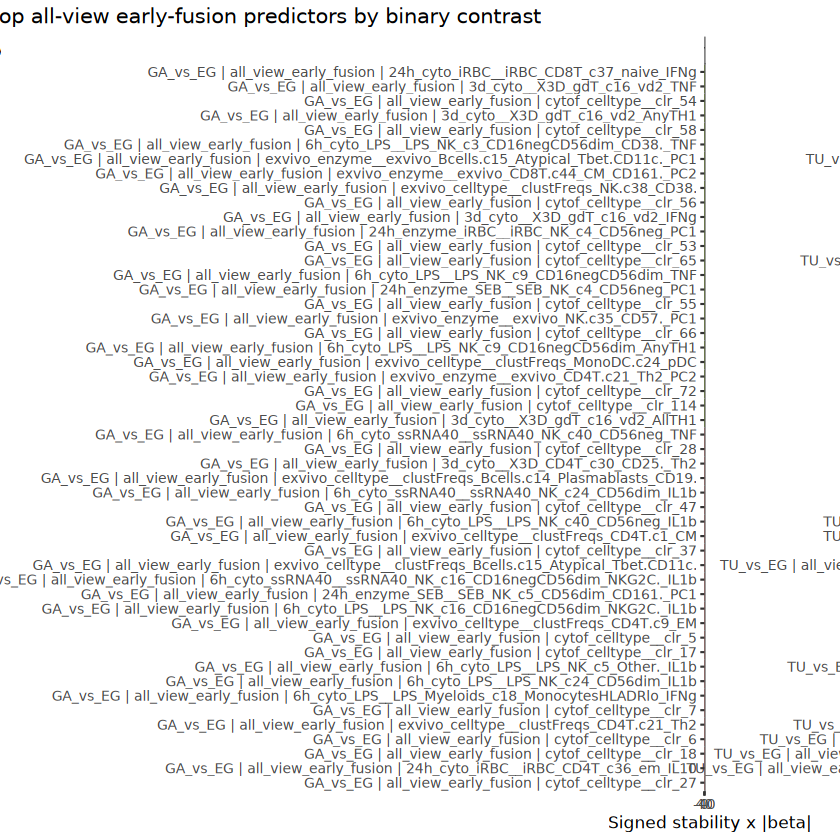

In [6]:
if (nrow(early_fusion_top_predictors) > 0L) {
  early_fusion_plot <- early_fusion_top_predictors |>
    dplyr::mutate(
      feature_label = paste(.data$contrast, .data$view, .data$feature, sep = " | "),
      signed_rank = ifelse(.data$beta >= 0, .data$rank_score, -.data$rank_score)
    ) |>
    ggplot2::ggplot(ggplot2::aes(x = stats::reorder(.data$feature_label, .data$signed_rank),
                                 y = .data$signed_rank, fill = .data$direction)) +
    ggplot2::geom_col() +
    ggplot2::coord_flip() +
    ggplot2::facet_wrap(~ contrast, scales = "free_y") +
    ggplot2::labs(title = "Top all-view early-fusion predictors by binary contrast",
                  x = NULL, y = "Signed stability x |beta|", fill = "Direction") +
    ggplot2::theme_bw(base_size = 10)
  early_fusion_plot
}


## Late Fusion Summaries

This section reads binary late-fusion weights, train predictions, confusion matrices, and metrics. The helper converts stacked probabilities to predicted classes using a `0.5` threshold.


In [7]:
late_fusion_weights <- purrr::imap_dfr(contrast_configs, function(config, contrast) {
  tbl <- load_table_if_exists(config, "late_fusion", "late_fusion_weights")
  if (is.null(tbl)) return(NULL)
  tbl |> dplyr::mutate(contrast = contrast, .before = 1L)
})

late_fusion_predictions <- purrr::imap_dfr(contrast_configs, function(config, contrast) {
  tbl <- load_table_if_exists(config, "late_fusion", "late_fusion_train_predictions")
  if (is.null(tbl)) return(NULL)
  tbl |> dplyr::mutate(contrast = contrast, .before = 1L)
})

late_fusion_confusion <- purrr::imap_dfr(contrast_configs, function(config, contrast) {
  tbl <- load_table_if_exists(config, "late_fusion", "late_fusion_confusion_matrix")
  if (is.null(tbl)) return(NULL)
  tbl |> dplyr::mutate(contrast = contrast, .before = 1L)
})

late_fusion_metrics <- purrr::imap_dfr(contrast_configs, function(config, contrast) {
  tbl <- load_table_if_exists(config, "late_fusion", "late_fusion_metrics")
  if (is.null(tbl)) return(NULL)
  tbl |> dplyr::mutate(contrast = contrast, .before = 1L)
})

late_fusion_weights
late_fusion_confusion
late_fusion_metrics


contrast,view,Associated_weight
<chr>,<chr>,<dbl>
EG_vs_GA_TU,cytof_celltype,5.634285661
EG_vs_GA_TU,exvivo_celltype,0.755546137
EG_vs_GA_TU,exvivo_enzyme,8.895881826
EG_vs_GA_TU,6h_cyto_LPS,6.403086092
EG_vs_GA_TU,6h_cyto_ssRNA40,5.809245841
EG_vs_GA_TU,24h_cyto_iRBC,4.992394578
EG_vs_GA_TU,24h_cyto_SEB,7.419174009
EG_vs_GA_TU,24h_enzyme_iRBC,9.063709483
EG_vs_GA_TU,24h_enzyme_SEB,5.652400437


contrast,truth,predicted,Freq
<chr>,<chr>,<chr>,<dbl>
EG_vs_GA_TU,GA_TU,GA_TU,28
EG_vs_GA_TU,EG,GA_TU,1
EG_vs_GA_TU,GA_TU,EG,0
EG_vs_GA_TU,EG,EG,9
GA_vs_EG,EG,EG,10
GA_vs_EG,GA,EG,0
GA_vs_EG,EG,GA,0
GA_vs_EG,GA,GA,16
TU_vs_EG,EG,EG,10


contrast,metric,value
<chr>,<chr>,<dbl>
EG_vs_GA_TU,accuracy,0.9736842
EG_vs_GA_TU,balanced_error_rate,0.0500000
EG_vs_GA_TU,macro_f1,0.9649123
EG_vs_GA_TU,stacking_auc,1.0000000
GA_vs_EG,accuracy,1.0000000
GA_vs_EG,balanced_error_rate,0.0000000
GA_vs_EG,macro_f1,1.0000000
GA_vs_EG,stacking_auc,1.0000000
TU_vs_EG,accuracy,1.0000000


## Cooperative Fusion Summaries

Cooperative fusion is modeled directly as a binomial branch for each requested comparison. These outputs are auxiliary sensitivity checks, not replacements for nested validation.


In [8]:
cooperative_diagnostics <- purrr::imap_dfr(contrast_configs, function(config, contrast) {
  tbl <- load_table_if_exists(config, "cooperative", "cooperative_diagnostics")
  if (is.null(tbl)) return(NULL)
  tbl |> dplyr::mutate(contrast = contrast, .before = 1L)
})

cooperative_features <- purrr::imap_dfr(contrast_configs, function(config, contrast) {
  tbl <- load_table_if_exists(config, "cooperative", "cooperative_features")
  if (is.null(tbl)) return(NULL)
  tbl |> dplyr::mutate(contrast = contrast, .before = 1L)
})

cooperative_diagnostics
cooperative_features


contrast,rho,lambda,metric_value,selected
<chr>,<dbl>,<dbl>,<dbl>,<lgl>
EG_vs_GA_TU,0.00,0.0183000623,0.21414280,TRUE
EG_vs_GA_TU,0.10,0.0004003040,0.29675493,FALSE
EG_vs_GA_TU,0.25,0.0001732946,0.29282600,FALSE
EG_vs_GA_TU,0.50,0.0001732636,0.31649535,FALSE
EG_vs_GA_TU,1.00,0.0001506781,0.33858747,FALSE
GA_vs_EG,0.00,0.0066848039,0.06285971,TRUE
GA_vs_EG,0.10,0.0011850295,0.48566758,FALSE
GA_vs_EG,0.25,0.0008557051,0.51673410,FALSE
GA_vs_EG,0.50,0.0008961933,0.57556842,FALSE


contrast,view,feature
<chr>,<chr>,<chr>
EG_vs_GA_TU,cytof_celltype,clr_6
EG_vs_GA_TU,cytof_celltype,clr_7
EG_vs_GA_TU,cytof_celltype,clr_27
EG_vs_GA_TU,cytof_celltype,clr_47
EG_vs_GA_TU,cytof_celltype,clr_54
EG_vs_GA_TU,cytof_celltype,clr_71
EG_vs_GA_TU,cytof_celltype,clr_91
EG_vs_GA_TU,exvivo_celltype,clustFreqs_Bcells.c15_Atypical_Tbet.CD11c.
EG_vs_GA_TU,exvivo_celltype,clustFreqs_CD4T.c21_Th2


## Visualization Artifacts

The visualization branch exports selected-feature heatmaps, PCA, UMAP, and late-fusion probability heatmaps under each contrast-specific output directory. This cell lists the cached figures without regenerating them.


In [9]:
cached_figures <- purrr::imap_dfr(contrast_configs, function(config, contrast) {
  dirs <- c(
    visualize = branch_export_dir(config, "visualize", "figures"),
    late_fusion = branch_export_dir(config, "late_fusion", "figures"),
    early_fusion = branch_export_dir(config, "early_fusion", "figures")
  )
  purrr::imap_dfr(dirs, function(path, branch) {
    files <- list.files(path, pattern = "[.](png|pdf)$", full.names = TRUE)
    tibble::tibble(contrast = contrast, branch = branch, figure = files)
  })
})

cached_figures


contrast,branch,figure
<chr>,<chr>,<chr>
EG_vs_GA_TU,late_fusion,/exports/para-lipg-hpc/mdmanurung/stablr/scratch/outputs/stablr_baseline_binary_comparisons/EG_vs_GA_TU/late_fusion/figures/prediction_probability_heatmap.pdf
EG_vs_GA_TU,late_fusion,/exports/para-lipg-hpc/mdmanurung/stablr/scratch/outputs/stablr_baseline_binary_comparisons/EG_vs_GA_TU/late_fusion/figures/prediction_probability_heatmap.png
EG_vs_GA_TU,early_fusion,/exports/para-lipg-hpc/mdmanurung/stablr/scratch/outputs/stablr_baseline_binary_comparisons/EG_vs_GA_TU/early_fusion/figures/all_view_top_predictors.pdf
EG_vs_GA_TU,early_fusion,/exports/para-lipg-hpc/mdmanurung/stablr/scratch/outputs/stablr_baseline_binary_comparisons/EG_vs_GA_TU/early_fusion/figures/all_view_top_predictors.png
GA_vs_EG,late_fusion,/exports/para-lipg-hpc/mdmanurung/stablr/scratch/outputs/stablr_baseline_binary_comparisons/GA_vs_EG/late_fusion/figures/prediction_probability_heatmap.pdf
GA_vs_EG,late_fusion,/exports/para-lipg-hpc/mdmanurung/stablr/scratch/outputs/stablr_baseline_binary_comparisons/GA_vs_EG/late_fusion/figures/prediction_probability_heatmap.png
GA_vs_EG,early_fusion,/exports/para-lipg-hpc/mdmanurung/stablr/scratch/outputs/stablr_baseline_binary_comparisons/GA_vs_EG/early_fusion/figures/all_view_top_predictors.pdf
GA_vs_EG,early_fusion,/exports/para-lipg-hpc/mdmanurung/stablr/scratch/outputs/stablr_baseline_binary_comparisons/GA_vs_EG/early_fusion/figures/all_view_top_predictors.png
TU_vs_EG,late_fusion,/exports/para-lipg-hpc/mdmanurung/stablr/scratch/outputs/stablr_baseline_binary_comparisons/TU_vs_EG/late_fusion/figures/prediction_probability_heatmap.pdf


## Interpretation Summary And Caveats

Use this section after the SLURM branches complete. Interpret features by contrast direction: positive beta values increase the log-odds of the positive class (`EG`, `GA`, or `TU` depending on the comparison); negative beta values point toward the reference class (`GA_TU` or `EG`). P/NP remains descriptive QC context only.

The cohort is small, the contrasts are imbalanced, and the default branch settings are feasibility-scale unless rerun with publication-scale bootstrap, nested-CV, and sensitivity settings.
